<a href="https://colab.research.google.com/github/fzkmdly/My_fraud_det_project_01/blob/main/FraudDetectionv2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Content:**
The dataset contains transactions made by credit cards in September 2013 by European cardholders.
This dataset presents transactions that occurred in two days, where we have 492 frauds out of 284,807 transactions. The dataset is highly unbalanced, the positive class (frauds) account for 0.172% of all transactions.

It contains only numerical input variables which are the result of a PCA transformation. Unfortunately, due to confidentiality issues, we cannot provide the original features and more background information about the data. Features V1, V2, … V28 are the principal components obtained with PCA, the only features which have not been transformed with PCA are 'Time' and 'Amount'. Feature 'Time' contains the seconds elapsed between each transaction and the first transaction in the dataset. The feature 'Amount' is the transaction Amount, this feature can be used for example-dependant cost-sensitive learning. Feature 'Class' is the response variable and it takes value 1 in case of fraud and 0 otherwise.

Given the class imbalance ratio, we recommend measuring the accuracy using the Area Under the Precision-Recall Curve (AUPRC). Confusion matrix accuracy is not meaningful for unbalanced classification.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import kagglehub

In [ ]:
path = kagglehub.dataset_download("mosapabdelghany/credit-card-fraud-detection")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'credit-card-fraud-detection' dataset.
Path to dataset files: /kaggle/input/credit-card-fraud-detection


# **Import Dataset**

In [ ]:
df = pd.read_csv('/kaggle/input/credit-card-fraud-detection/creditcard.csv')

df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [ ]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [ ]:
df['Class'].unique()

array([0, 1])

In [ ]:
df['Class'].value_counts()

,count
Class,
0,284315
1,492


In [ ]:
df.Class.value_counts()

,count
Class,
0,284315
1,492


# **Data Cleaning**

In [ ]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [ ]:
df.duplicated().sum()

np.int64(1081)

In [ ]:
df = df.drop_duplicates()

df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [ ]:
df['Class'].value_counts()

,count
Class,
0,283253
1,473


# **Explanatory Data Analysist**

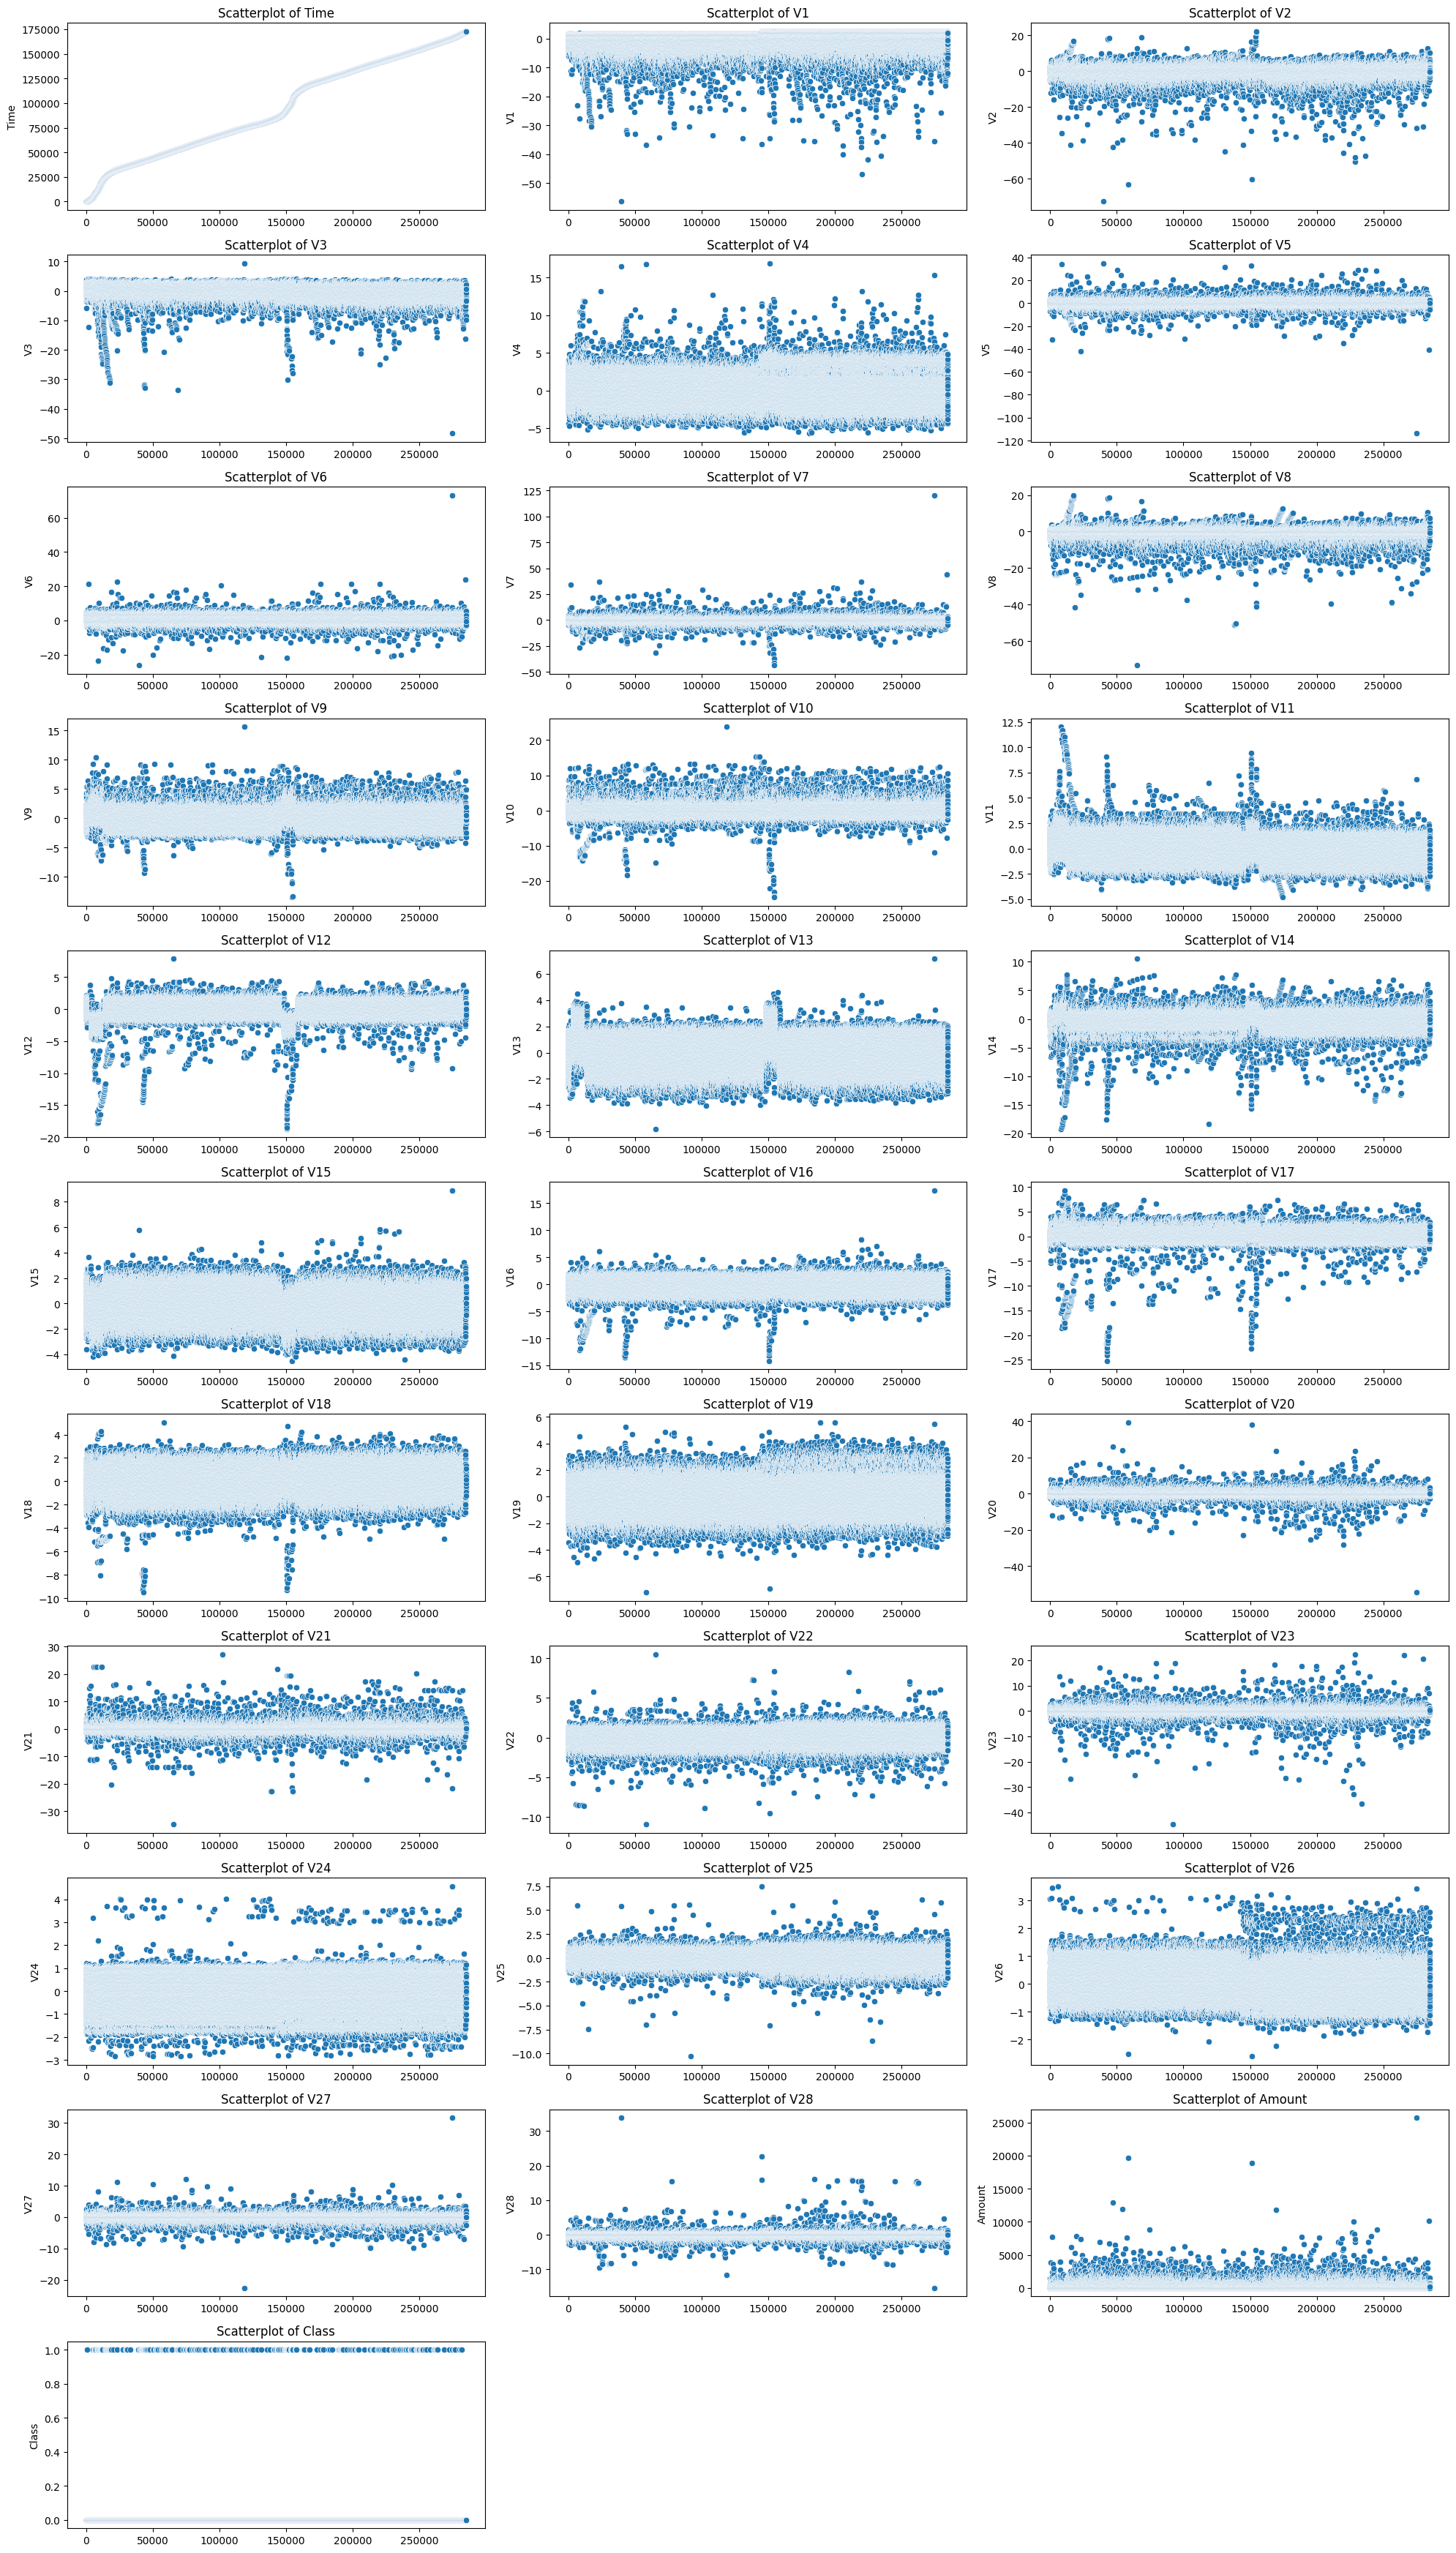

In [ ]:
n_cols = 3
n_rows = math.ceil(31 / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 35))

axes = axes.flatten()

for i, col in enumerate(df.columns):
  sns.scatterplot(df[col], ax=axes[i])
  axes[i].set_title(f"Scatterplot of {col}")

for j in range(len(df.columns), len(axes)):
  fig.delaxes(ax=axes[j])

plt.tight_layout()
plt.show()

<Axes: >

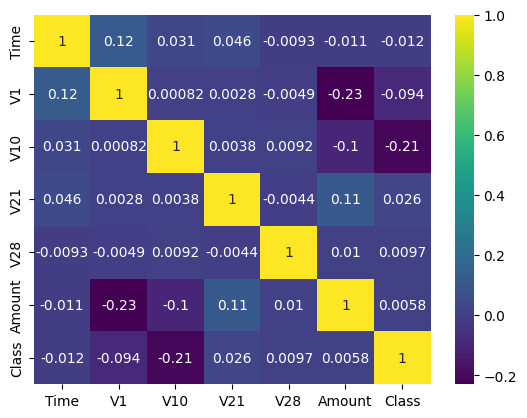

In [ ]:
heatMP = df[['Time', 'V1', 'V10', 'V21', 'V28', 'Amount', 'Class']].corr()

sns.heatmap(heatMP, cmap='viridis', annot=True)

Penjelasan :

Dari heatmap di atas, diantara semua fitur, hampir tidak ada fitur yang mempunyai hubungan kuat dengan fitur lainnya.

# **Scaling**

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler_ = StandardScaler()

copied_df = df.copy()

copied_df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [ ]:
copied_df['Amount'] = scaler_.fit_transform(copied_df[['Amount']])

copied_df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0.244200,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-0.342584,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,1.158900,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0.139886,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,-0.073813,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,-0.350252,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,-0.254325,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,-0.082239,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,-0.313391,0


# **Modeling**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
import xgboost as xgb

In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    median_absolute_error
)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

## **Data Splitting**

In [ ]:
x = copied_df.iloc[:, 1:-1]
y = copied_df['Class']

print(30*'=')
print('Value counts for y')
print(y.value_counts())

Value counts for y
Class
0    283253
1       473
Name: count, dtype: int64


## **Balancing the Value using SMOTE technique**

In [ ]:
smote = SMOTE()

x_rev, y_rev = smote.fit_resample(x, y)

print(30*'=')
print('Value counts for y')
print(y_rev.value_counts())

Value counts for y
Class
0    283253
1    283253
Name: count, dtype: int64


In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x_rev, y_rev, test_size=0.3, random_state=42)

## Model



1. XGBoost
2. Linear Regression
3. Decision Tree



In [ ]:
scoring = pd.DataFrame(columns=["Model_Name", "Accuracy", "Precision", "Recall", "F1_Score"])

### XGBoost

In [ ]:
XGB_model = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

XGB_model.fit(x_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
# 4. Predict and evaluate
y_predXGB = XGB_model.predict(x_test)
acc = round(accuracy_score(y_test, y_predXGB), 4)
prec = round(precision_score(y_test, y_predXGB), 4)
rec = round(recall_score(y_test, y_predXGB), 4)
f1 = round(f1_score(y_test, y_predXGB), 4)

print("Accuracy :", acc)
print("Precision:", prec)
print("Recall   :", rec)
print("F1 Score :", f1)

Accuracy : 0.9942
Precision: 0.9939
Recall   : 0.9944
F1 Score : 0.9942


In [ ]:
mae = round(mean_absolute_error(y_test, y_predXGB), 4)
mse = round(mean_squared_error(y_test, y_predXGB), 4)

print(f'MAE : {mae}')
print(f'MSE : {mse}')

MAE : 0.0058
MSE : 0.0058


In [ ]:
scoring.loc[len(scoring)] = ['XGBoost', acc, prec, rec, f1]

scoring

,Model_Name,Accuracy,Precision,Recall,F1_Score
0,XGBoost,0.9942,0.9939,0.9944,0.9942


### Logistic Regression

In [ ]:
LR_model = LogisticRegression(solver='lbfgs', random_state=42)

LR_model.fit(x_train, y_train)

LogisticRegression(random_state=42)

In [ ]:
y_predLR = LR_model.predict(x_test)
acc = round(accuracy_score(y_test, y_predLR), 4)
prec = round(precision_score(y_test, y_predLR), 4)
rec = round(recall_score(y_test, y_predLR), 4)
f1 = round(f1_score(y_test, y_predLR), 4)

print("Accuracy :", acc)
print("Precision:", prec)
print("Recall   :", rec)
print("F1 Score :", f1)

Accuracy : 0.944
Precision: 0.9725
Recall   : 0.914
F1 Score : 0.9423


In [ ]:
mae = round(mean_absolute_error(y_test, y_predLR), 4)
mse = round(mean_squared_error(y_test, y_predLR), 4)
# r2_score = round(r2_score(y_test, y_predLR), 4)

print(f'MAE : {mae}')
print(f'MSE : {mse}')

MAE : 0.056
MSE : 0.056


In [ ]:
scoring.loc[len(scoring)] = ['Logistic Regression', acc, prec, rec, f1]

scoring

,Model_Name,Accuracy,Precision,Recall,F1_Score
0,XGBoost,0.9942,0.9939,0.9944,0.9942
1,Logistic Regression,0.9440,0.9725,0.9140,0.9423


### Decision Tree

In [ ]:
DTModel = DecisionTreeClassifier()

DTModel.fit(x_train, y_train)

DecisionTreeClassifier()

In [ ]:
y_predDT = DTModel.predict(x_test)
acc = round(accuracy_score(y_test, y_predDT), 4)
prec = round(precision_score(y_test, y_predDT), 4)
rec = round(recall_score(y_test, y_predDT), 4)
f1 = round(f1_score(y_test, y_predDT), 4)

print("Accuracy :", acc)
print("Precision:", prec)
print("Recall   :", rec)
print("F1 Score :", f1)

Accuracy : 0.9979
Precision: 0.997
Recall   : 0.9988
F1 Score : 0.9979


In [ ]:
mae = round(mean_absolute_error(y_test, y_predDT), 4)
mse = round(mean_squared_error(y_test, y_predDT), 4)

print(f'MAE : {mae}')
print(f'MSE : {mse}')

MAE : 0.0021
MSE : 0.0021


In [ ]:
scoring.loc[len(scoring)] = ['Decision Tree', acc, prec, rec, f1]

scoring

,Model_Name,Accuracy,Precision,Recall,F1_Score
0,XGBoost,0.9942,0.9939,0.9944,0.9942
1,Logistic Regression,0.9440,0.9725,0.9140,0.9423
2,Decision Tree,0.9979,0.9970,0.9988,0.9979


# Evaluation

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

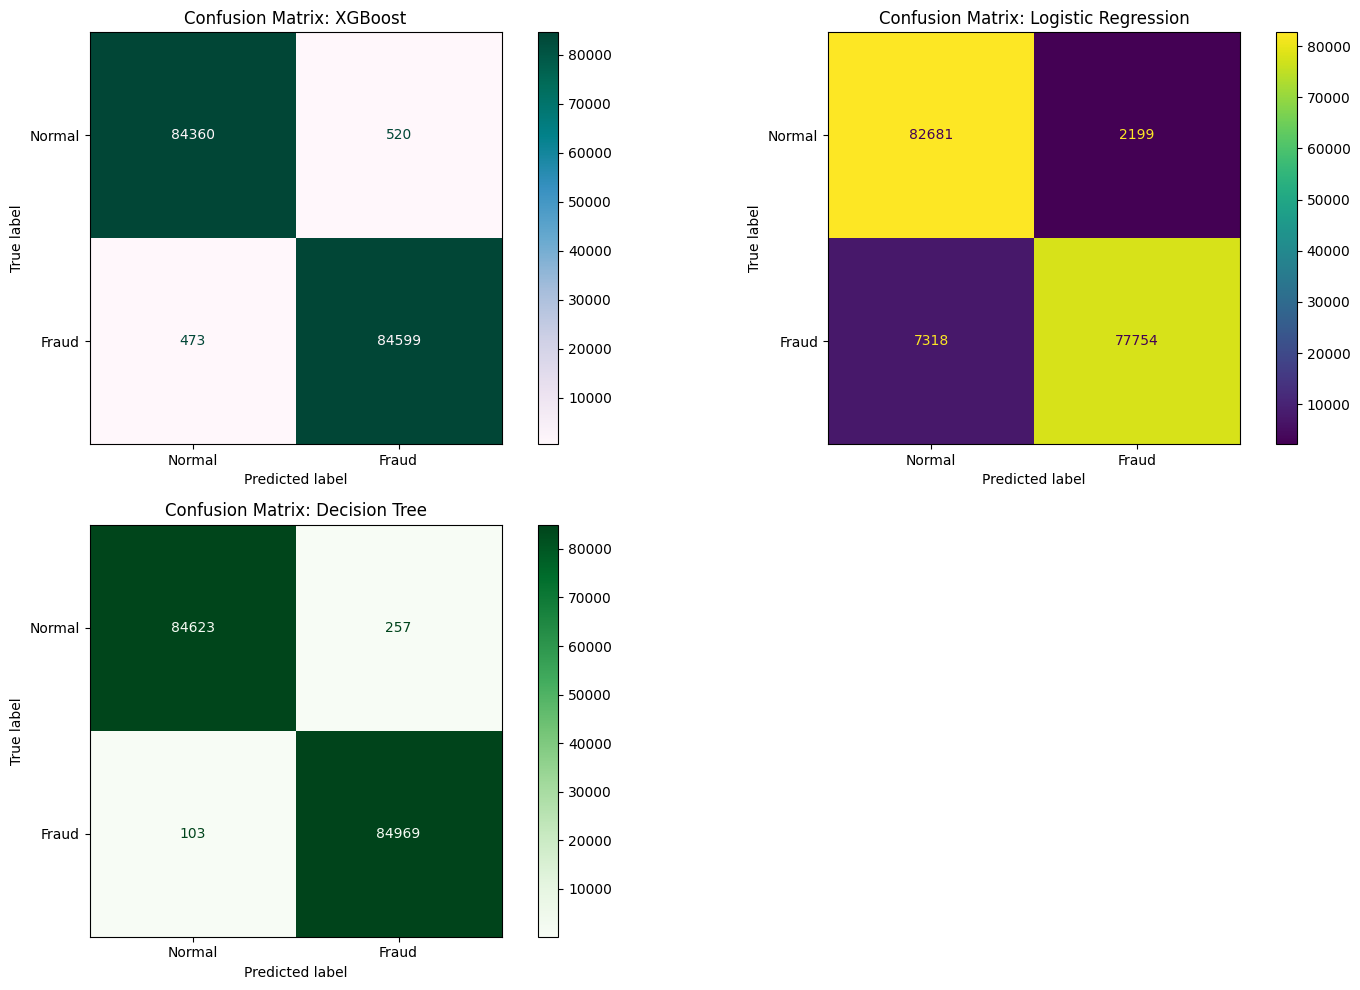

In [ ]:
# List of your predictions
pred_model = [y_predXGB, y_predLR, y_predDT]
model_names = ['XGBoost', 'Logistic Regression', 'Decision Tree']
cmap_color = [plt.cm.PuBuGn, plt.cm.viridis, plt.cm.Greens]

# 1. Created a cleaner vertical layout (10 inches wide, 15 inches high total)
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

# 2. Use enumerate to match the prediction data to its dedicated subplot axis
for idx, y_pred in enumerate(pred_model):
    cm = confusion_matrix(y_test, y_pred)

    # Define labels properly as a single flat list
    displ = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Fraud'])

    # CRITICAL FIX: Pass the specific subplot axis to the plot method
    displ.plot(cmap=cmap_color[idx], ax=axes[idx])

    # Optional: Add a title to each subplot to tell models apart
    axes[idx].set_title(f"Confusion Matrix: {model_names[idx]}")

for j in range(len(pred_model), len(axes)):
  fig.delaxes(ax=axes[j])

plt.tight_layout()
plt.show()


**Penjelasan :**

Pada grafik confusion matriks di atas, bisa disimpulkan bahwa model Decision Tree dan XGBoost memiliki performa yang ideal dalam mendeteksi penipuan. Namun secara keseluruhan, Decision Tree adalah pilihan terbaik dari kedua model lainnya dimana model ini dapat mendeteksi true positive dan true negative dalam angka deteksi yang lebih besar, dengan prediksi *missed* 93 kasus penipuan. Decision Tree sangat cocok jika model digunakan untuk mengurangi kerugian finansial atau *minimizing financial loss*. Model ini juga cocok untuk memastikan pengalaman pengguna yang lancar/tanpa hambatan dalam bertransaksi, ini dibuktikan dari angka false positive (terdeteksi fraud yang seharusnya transaksi normal) sebanyak 266 terdeterksi fraud.

**Explanation :**

Based on the confusion matrix plots above, it can be concluded that both the Decision Tree and XGBoost models demonstrate ideal performance in detecting fraud. Overall, however, the Decision Tree is the best choice among the three models, as it accurately detects a higher number of true positives and true negatives, with only 93 fraud cases missed. The Decision Tree is highly suitable for minimizing financial loss. Additionally, it is well-suited for ensuring a seamless user experience during transactions, as evidenced by its low false positive count (normal transactions incorrectly flagged as fraud) of only 266 cases.

In [ ]:
display(scoring)

,Model_Name,Accuracy,Precision,Recall,F1_Score
0,XGBoost,0.9942,0.9939,0.9944,0.9942
1,Logistic Regression,0.9440,0.9725,0.9140,0.9423
2,Decision Tree,0.9979,0.9970,0.9988,0.9979


**Penjelasan :**

Berdasarkan tabel scoring, Matriks evaluasi menunjukkan bahwa performa Decision Tree lebih unggul dan stabil dari dua model lainnya.

Model Decision Tree mendapatkan nilai akurasi sebesar 99.79% dan F1_score 0.9979, sedikit lebih unggul dari kompetitor terdekatnya yaitu XGBoost. Secara spesifik, angka persentase 99.88% untuk nilai recall menunjukkan model Decision Tree mampu mendeteksi hampir seluruh transaksi, meminimalisir misses (93 kasus) dan mengurangi resiko kerugian finansial. Di saat yang bersamaan, nilai Precision sebesar 99,70% memastikan bahwa transaksi sah sangat jarang salah diidentifikasi, sehingga meminimalkan friksi operasional dan menjaga kenyamanan pengalaman pengguna dengan hanya menghasilkan 266 temuan positif palsu (false positive).

Meskipun XGBoost memberikan hasil yang kompetitif dan kuat dengan nilai F1-Score sebesar 99,42%, performanya masih sedikit di bawah Decision Tree dalam hal efisiensi deteksi. Sementara itu, Logistic Regression tertinggal jauh di belakang dengan tingkat Akurasi (94,40%) dan Recall (91,40%) yang lebih rendah. Hal ini membuat Logistic Regression tidak cocok digunakan untuk tugas deteksi penipuan yang berisiko tinggi ini karena besarnya volume penipuan yang gagal terdeteksi.

**Explanation :**

Based on the scoring summary table and confusion matrices, the evaluation metrics confirm that the Decision Tree outperforms all other models across every key performance indicator.

The Decision Tree achieved the highest Accuracy (99.79%) and F1-Score (0.9979), demonstrating an exceptionally robust balance between precision and recall. Specifically, its top-tier Recall of 99.88% means it successfully identifies almost all fraudulent transactions, minimizing missed cases (only 93 missed) and drastically reducing risk exposure (financial loss). Simultaneously, its Precision of 99.70% ensures that genuine transactions are rarely misclassified, minimizing operational friction and maintaining a seamless user experience with only 266 false positives.

While XGBoost delivers strong, competitive results with an F1-Score of 99.42%, it still falls slightly short of the Decision Tree in efficiency. Meanwhile, Logistic Regression lags significantly behind with a lower Accuracy (94.40%) and Recall (91.40%), making it unsuitable for this high-stakes fraud detection task due to the high volume of undetected fraud.

# Export File

In [ ]:
import joblib

In [ ]:
joblib.dump(DTModel, "Decision_Tree_Model.pkl")

['Decision_Tree_Model.pkl']